In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from lightgbm import LGBMClassifier
from sklearn.cluster import KMeans
sns.set_theme()

In [95]:
df = pd.read_csv(
    r'C:\Fause\Programas\EngSoft\repos\ML-Transportes\PBIC\Etapa3\acidentes_pbic_2020_2025_Final.csv',
    encoding='utf-8',
    parse_dates=['data_inversa'],
    dayfirst=True,
    low_memory=False
)

print("Shape inicial:", df.shape)


Shape inicial: (1678326, 48)


In [96]:
df["severity_index"] = (
    4 * df["mortos"] +
    2 * df["feridos_graves"] +
    1 * df["feridos_leves"]
)

# --- Target transformada para ML ---
df["severity_index_log"] = np.log1p(df["severity_index"])


df["km"] = (
    df["km"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df["km"] = pd.to_numeric(df["km"], errors="coerce")

df = df.dropna(subset=["km"])



In [97]:
df["km_bin"] = (df["km"] // 5) * 5   # segmentos de 5 km

df_segmento = df.groupby(["br", "uf", "km_bin"]).agg({
    "severity_index": "mean",
    "id": "count"
}).reset_index()

df_segmento.rename(columns={"id": "n_acidentes"}, inplace=True)

df_segmento["score_risco"] = ( df_segmento["severity_index"] * np.log1p(df_segmento["n_acidentes"]))

df_segmento = df_segmento.sort_values("score_risco", ascending=False)

In [98]:
df["severity_log"] = np.log1p(df["severity_index"])

df = df[df["severity_index"] >= 0]

df["idade_veiculo"] = 2025 - df["ano_fabricacao_veiculo"]

df["latitude"] = (
    df["latitude"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df["longitude"] = (
    df["longitude"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")

In [99]:
features = [
    "uf",
    "br",
    "km_bin",
    "hora",
    "mes",
    "dia_semana",
    "tipo_acidente",
    "fase_dia",
    "condicao_metereologica",
    "tipo_pista",
    "tracado_via",
    "uso_solo", #*
    "tipo_veiculo",
    "idade",
    "idade_veiculo",
    'latitude', 
    'longitude',
    'regional', 
    'Fabricante',
    'Modelo'
]

df = df.dropna(subset=["severity_log"])

for col in features:
    
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
        
    else:
        df[col] = df[col].fillna("Desconhecido")


categoricas = df[features].select_dtypes(include="object").columns

for col in categoricas:
    df[col] = df[col].astype("category")

X = df[features]
y = df["severity_log"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

C:\Users\fause\AppData\Local\Temp\ipykernel_25188\2020907497.py:35: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df[features].select_dtypes(include="object").columns


In [100]:
import lightgbm as lgb

# modelo = lgb.LGBMRegressor(
#     n_estimators=400,
#     learning_rate=0.05,
#     num_leaves=64,
#     random_state=42,
#     n_jobs=-1,
#     force_col_wise=True,
#     max_bin=512

# )

modelo = lgb.LGBMRegressor(
    n_estimators=800,          # mais árvores
    learning_rate=0.03,        # aprendizado mais suave
    num_leaves=128,            # mais capacidade
    max_depth=-1,              # sem limite explícito
    min_child_samples=40,      # evita overfitting
    subsample=0.8,             # bagging
    colsample_bytree=0.8,      # feature sampling
    reg_alpha=0.5,             # regularização L1
    reg_lambda=0.5,            # regularização L2
    random_state=42,
    n_jobs=-1,
    force_col_wise=True,
    max_bin=512
)

modelo.fit(X_train, y_train)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Total Bins 2788
[LightGBM] [Info] Number of data points in the train set: 1338817, number of used features: 20
[LightGBM] [Info] Start training from score 0.441544


,boosting_type,'gbdt'
,num_leaves,128
,max_depth,-1
,learning_rate,0.03
,n_estimators,800
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,40


In [101]:
# import shap
# import numpy as np

# # pegar amostra aleatória pequena
# X_sample = X_test.sample(5000, random_state=42)

# explainer = shap.TreeExplainer(modelo)
# shap_values = explainer.shap_values(X_sample)

# shap.summary_plot(shap_values, X_sample)

In [102]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

pred = modelo.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 0.33138542738694043
R2: 0.5455672453204056


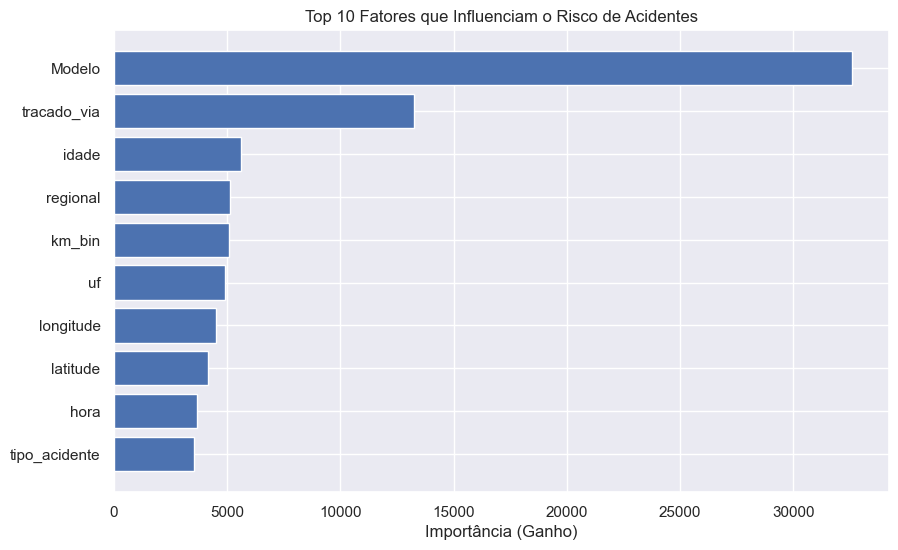

In [103]:
import matplotlib.pyplot as plt

# Pegando a importância das colunas
importancias = pd.DataFrame({
    'feature': X_train.columns,
    'importancia': modelo.feature_importances_
}).sort_values('importancia', ascending=False)

# Plotando
plt.figure(figsize=(10, 6))
plt.barh(importancias['feature'][:10], importancias['importancia'][:10])
plt.xlabel("Importância (Ganho)")
plt.title("Top 10 Fatores que Influenciam o Risco de Acidentes")
plt.gca().invert_yaxis()
plt.show()

In [104]:
importances = pd.DataFrame({
    "feature": X.columns,
    "importance": modelo.feature_importances_
}).sort_values("importance", ascending=False)

print(importances)

                   feature  importance
19                  Modelo       32581
10             tracado_via       13251
13                   idade        5602
17                regional        5114
2                   km_bin        5076
0                       uf        4894
16               longitude        4498
15                latitude        4140
3                     hora        3671
6            tipo_acidente        3539
18              Fabricante        3130
5               dia_semana        3101
14           idade_veiculo        3085
1                       br        2282
4                      mes        2251
12            tipo_veiculo        1568
8   condicao_metereologica        1522
7                 fase_dia         786
9               tipo_pista         766
11                uso_solo         743


In [105]:
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores = cross_val_score(modelo, X, y, cv=kf, scoring='r2')

print("R2 por fold:", r2_scores)
print("R2 médio:", np.mean(r2_scores))
print("Desvio padrão:", np.std(r2_scores))

rmse_scores = -cross_val_score(modelo, X, y, cv=kf,
                                scoring='neg_root_mean_squared_error')

print("RMSE médio:", np.mean(rmse_scores))

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Total Bins 2778
[LightGBM] [Info] Number of data points in the train set: 1338817, number of used features: 20
[LightGBM] [Info] Start training from score 0.441544
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Total Bins 2774
[LightGBM] [Info] Number of data points in the train set: 1338817, number of used features: 20
[LightGBM] [Info] Start training from score 0.440995
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_f

In [106]:
# import shap

# explainer = shap.TreeExplainer(modelo)
# shap_values = explainer.shap_values(X_test)

# shap.summary_plot(shap_values, X_test)

In [107]:
# print("\nSeveridade média por fase do dia:")
# print(df.groupby("fase_dia")["severity_index"].mean())

# print("\nSeveridade média por tipo de pista:")
# print(df.groupby("tipo_pista")["severity_index"].mean())

# print("\nSeveridade média por condição meteorológica:")
# print(df.groupby("condicao_metereologica")["severity_index"].mean())

# print("\nTop 10 tipos de acidente mais severos:")
# print(
#     df.groupby("tipo_acidente")["severity_index"]
#     .mean()
#     .sort_values(ascending=False)
#     .head(10)
# )

In [108]:
print("Linhas atuais:", len(df))

Linhas atuais: 1673522


In [109]:
# =============================
# 📊 Totais gerais
# =============================

total_acidentes = len(df)
total_segmentos = len(df_segmento)

print("Total de acidentes no dataset:", total_acidentes)
print("Total de segmentos analisados:", total_segmentos)

Total de acidentes no dataset: 1673522
Total de segmentos analisados: 12157


In [110]:
print("Shape inicial:", df.shape)

Shape inicial: (1673522, 53)
